# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?\
**Linear models are limited because they estimate in a straight line and gave predictions based on an 'x' and 'b'. In addition, linear models cannot restrict the output, which is important when we are looking at possibilities (0-1), count data, and survival data. Adding activation functions makes the model able to bend and have curves, allowing it to capture more of the complexity. Rather than a straight line, the model will be able to predict with more parameters. With a latent variable model, hidden and unobserved variables are included when modeling. Certain effects that aren't physically in numbers can be captured which allows a model to be more complex than a simple linear model. A general linear model can capture different outcomes and transformations such as possibility outcomes (between 0 and 1), and count data.**
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.\
**The binary cross entropy is effective for fitting logistic regression models because binary classfication itself also outputs a number between 0 and 1, just like a logistic regression model. The cross entropy part measures how good the model is at outputing the correct number between 0 and 1, so they are effective loss functions for fitting logistic regression models. For categorical cross entropy, the loss is dependent on how much probability is assigned to the right answer, which is also in line with what a logistic regression would output. A higher probability to the right answer means less loss, which is good.**
3. True or false, and explain: Logistic regression is a linear model.
**True, because logistic regression computes the linear combination of its inputs. The model itself is linear because it is multiplying by something and then adding. However, the output may not be linear because it must be passed through a non linear function like the sigmoid for the final prediction.**
4. True or false, and explain: Logistic regression cannot be used for classification.\
**False, because logistic regression outputs the porbability between 0 and 1 that something belongs in a category. It uses a threshold to categorize its predictions.**
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?\
**No, because logistic regression models in terms of log. I lowkey don't understand/don't want to understand log, but because the coefficient is in terms of log, it means that a 1 unit increase in the feature means that the coefficient increases in the log-odds of the outcome. There is no direct change to the coefficient**
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.\
**False, because feature engineering is still necessary, regardless of whether or not the model is linear. While non-linear models need feature engineering less than linear models, a non-linear model can still benefit from feature engineering. In addition, logistic regression still has a linear model, the output may be non-linear, but the core model is linear.**
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.\
**False, because logistic regression is used to run regression a different way than a ordinary least squares linear model. It outputs categorical predictions, so for classification, it works better than linear. However, for continuous variables, OLS is better. They both work, but for different things.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.\
**No missing values were found so they were not handled.**

In [8]:
df = pd.read_csv("data/data.csv", delimiter = ";")
df.columns
df = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 
       'Curricular units 1st sem (approved)',
     'Unemployment rate','Target']]
print(df.isna().sum())
df["binary_target"] = df["Target"].map({
    "Dropout": 1,
    "Graduate":0,
    "Enrolled":0
})
df.head()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Unemployment rate                      0
Target                                 0
dtype: int64


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Unemployment rate,Target,binary_target
0,0,1,0,20,0,10.8,Dropout,1
1,0,0,0,19,6,13.9,Graduate,0
2,0,0,0,19,0,10.8,Dropout,1
3,0,1,0,20,6,9.4,Graduate,0
4,0,1,0,45,5,13.9,Graduate,0


2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?\
**Being in debt leads to a higher dropout probability, whicle having up to date tutions drastically lower dropout probability. Being up to date on tuition does seem to reduce dropout risk.**

In [39]:
from sklearn.linear_model import LogisticRegression
y = df["binary_target"]
X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
model = LogisticRegression(penalty=None).fit(X,y)
model_coef = pd.DataFrame(model.coef_)
model_coef = model_coef.set_axis(model.feature_names_in_,axis=1)
print('Coefficients for each landmine type:')
print(model_coef)
np.exp(model_coef)

Coefficients for each landmine type:
     Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment
0  0.527137                -2.605617           -1.242299           0.049841


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment
0,1.694076,0.073858,0.28872,1.051104


3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?\
**Being up to date on tuition generally has lower dropout rates, however, the younger the individuals, the bigger the gap between the two. Around 30ish is when the gap between up to date tuition and not up to date tuition is the biggest, which represents the age where up to date tuition matters the most. On average, being up to date on tution drops the predicted probability of dropout by about 61%.**

<Axes: xlabel='Age at enrollment', ylabel='dropout_prob'>

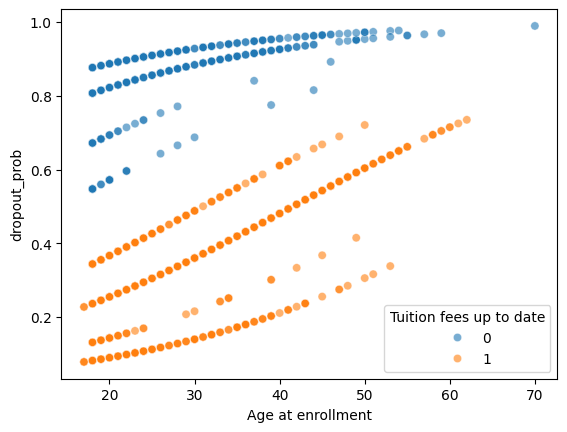

In [40]:
prob = model.predict_proba(X)
df["dropout_prob"] = prob[:, 1]
sns.scatterplot(data=df, x="Age at enrollment", y="dropout_prob", hue="Tuition fees up to date", alpha=0.6)

In [41]:
avg_probs = df.groupby("Tuition fees up to date")["dropout_prob"].mean()
effect = avg_probs[0] - avg_probs[1]
print(effect)

0.6181006148688428


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?\
**The accuracy is about 76%.**


In [42]:
tab = pd.crosstab(y, model.predict(X)) 
acc = np.trace(tab)/len(y) # Accuracy
print(tab)
print('Accuracy: ', acc)

col_0             0    1
binary_target           
0              2841  162
1               891  530
Accuracy:  0.7619801084990958


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.\
**The performance in terms of shape for both are very similar. However, visibly, you can see that orange or the logistic regression is constrained to 0 and 1, whereas for linear, it is more spread out. In addition, the count for linear is on average, higher than the count for logistic regression. In terms of performance, I think the logistic regression provides a more constrained and concentrated probability, especially since this is a classification problem.**

<Axes: xlabel='lin_prob', ylabel='Count'>

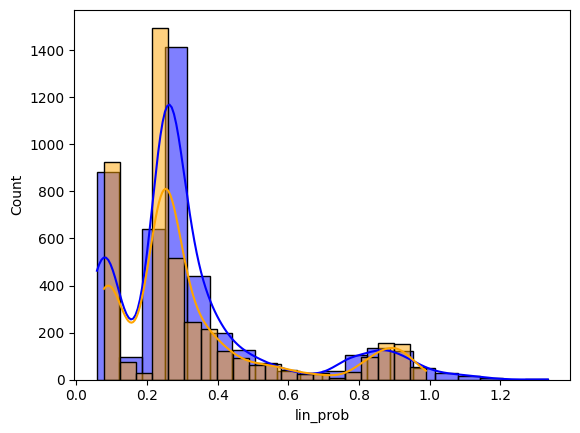

In [38]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X, y)
df["lin_prob"] = lin_model.predict(X)
df["log_prob"] = reg.predict_proba(X)[:, 1]
sns.histplot(data = df["lin_prob"], bins = 20, kde = True, color = "blue")
sns.histplot(data = df["log_prob"], bins = 20, kde = True, color = "orange")

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?
**The biggest contributing to students dropping out is tuition. If tuition is up to date, we can see that just being up to date on tuition drops the risk of dropping out by 61%. Some interventions I can think of is more student aid, especially from the college itself. Giving students financial security is very important because tuition seems to be a big reason for student drop-out. In addition, some preventative measures can be taken so that students consistently up to date with their tuition, such as offering more work-studies so that students can pay off their debt while learning. The next biggest contributor is being in debt. Being in debt significantly increases the chance of the student dropping out. Again, more work opportunities and more financial aid can help.Financial courses for personal finance may help in the long run for the students as well.**

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?\
**The result of running a multinomial logistic regression is that enrolled doesn't even exist. This model does not ever predict enrolled and only classifies individuals as Dropouts or Graduates.It performs relatively well for actual Dropouts and actual Graduates, however, it completely miss-predicts the enrolled section. Hard classification did not manage to predict every class. It missed enrolled completly. Predicted probabilities, however, did manage to capture all 3 classes. It gives a probability for every class rather than just picking the ones with higher probability.**

In [117]:
X_multi = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = df["Target"]
multi_model = LogisticRegression(solver="lbfgs", max_iter=1000)
multi_model.fit(X_multi, y_multi)
y_pred = multi_model.predict(X_multi)

tab_multi = pd.crosstab(y_multi, multi_model.predict(X_multi)) 
acc_multi = np.trace(tab_multi)/len(y_multi) # Accuracy
print(tab_multi)


col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063


In [ ]:
pd.DataFrame(multi_model.predict_proba(X_multi), columns=multi_model.classes_)


,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104
...,...,...,...
4419,0.184227,0.212669,0.603104
4420,0.784988,0.149758,0.065253
4421,0.071938,0.140644,0.787418
4422,0.184227,0.212669,0.603104


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.\
**For missing values, I looked at how many there were for each column. "Stage" had only 6 missing values so I dropped those. "Drug", however, has 100 missing values after that so I used mode imputation on it. Originally, I wanted to use median, however, since it was categorical, the median would not make sense.**

In [84]:
df_cirr = pd.read_csv("data/cirrhosis.csv")
df_cirr = df_cirr[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df_cirr = df_cirr.dropna(subset = ["Stage"])
df_cirr["Drug"] = df_cirr["Drug"].fillna(df_cirr["Drug"].mode()[0])
df_cirr.isna().sum()


Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?\
**The drugs do not impact status very much with all the coefficients very close to 0. Having bilirubin multiplies the odds of death of a moderate 1.15. Higher bilirubin levels typically correlate stronger with death, while lower bilirubin correlates more with C (alive). Survival rate is dire with edema. Compared to when there is no edema, having restricted edema multiplies the probability of death by 22.7, which is really bad. In contrast, having controlled edema only multplies the probability of death by 1.6.**


In [98]:
y_cirr = df_cirr["Status"]
X_cirr = pd.get_dummies(
    df_cirr[["Edema", "Drug", "Bilirubin"]],
    drop_first=True
)
model_cirr = LogisticRegression(penalty=None).fit(X_cirr,y_cirr)
model_cirr_coef = pd.DataFrame(model_cirr.coef_)
model_cirr_coef = model_cirr_coef.set_axis(model_cirr.feature_names_in_,axis=1)
print('Coefficients for each Survival Decider type:')
print(model_cirr_coef)
print(model_cirr.classes_)
np.exp(model_cirr_coef)

Coefficients for each Survival Decider type:
   Bilirubin   Edema_S   Edema_Y  Drug_Placebo
0  -0.233001 -0.548933  0.270301      0.029422
1   0.086738  0.051784 -3.393873     -0.019330
2   0.146264  0.497149  3.123572     -0.010093
['C' 'CL' 'D']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Bilirubin,Edema_S,Edema_Y,Drug_Placebo
0,0.792152,0.577566,1.310359,1.029859
1,1.090611,1.053148,0.033578,0.980856
2,1.157501,1.644028,22.727415,0.989958


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?\
**The drug vs the placebo seems to have no strong impact on increasing patient survival rate with the blue and orange often overlapping. Hwoever, from 1 through 15, the druge D-penicillamine seems to break away from the line of placebos, though there are still some who have a low survival rate anyways. On average the patients who take the drug increase their probability by about 1%, which is positive but like a weak result.**

<Axes: xlabel='Bilirubin', ylabel='survival_prob'>

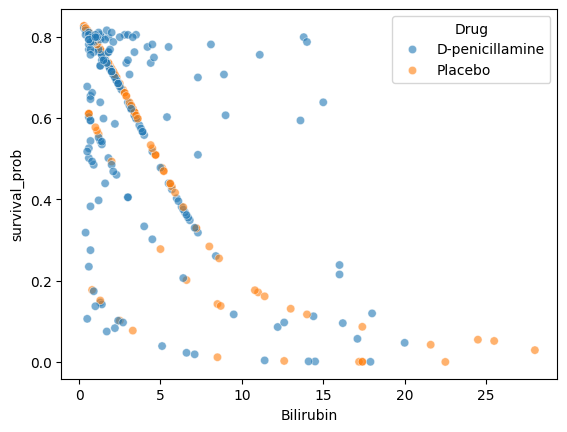

In [102]:
prob_cirr = pd.DataFrame(model_cirr.predict_proba(X_cirr),columns=model_cirr.classes_)
df_cirr["survival_prob"] = 1 - prob_cirr["D"]
sns.scatterplot(data=df_cirr, x="Bilirubin", y="survival_prob", hue="Drug", alpha=0.6)

In [106]:
avg_survival = df_cirr.groupby("Drug")["survival_prob"].mean()

effect = avg_survival["D-penicillamine"] - avg_survival["Placebo"]

print("Average survival probability:")
print(avg_survival)

print("Increase due to drug:", effect)

Average survival probability:
Drug
D-penicillamine    0.625627
Placebo            0.610486
Name: survival_prob, dtype: float64
Increase due to drug: 0.015141357266294064


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?\
**The accuracy is 0.52. However, CL disappears, which can impact the accuracy of the model.**

In [110]:
tab_cirr = pd.crosstab(y_cirr, model_cirr.predict(X_cirr)) 
acc_cirr = np.trace(tab_cirr)/len(y_cirr) # Accuracy
print(tab_cirr)
print('Accuracy: ', acc_cirr)

col_0     C   D
Status         
C       209  21
CL       19   6
D        77  80
Accuracy:  0.5218446601941747


5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.\
**Both follow the same shape, however, the log probaility (in orange) is restricted between 0 and 1, like in question two. Similar to question 2 as well, the linear model is a lot more spread out, having a higher count on average. The linear plot also goes into the negatives, which is not interpretable for survival probabilities. Overall, the logistic model is a little more interpretable because our y is status, which is categorical. We can read the probability easily with the logistic model whereas we cannot with the linear model.**

<Axes: xlabel='lin_prob', ylabel='Count'>

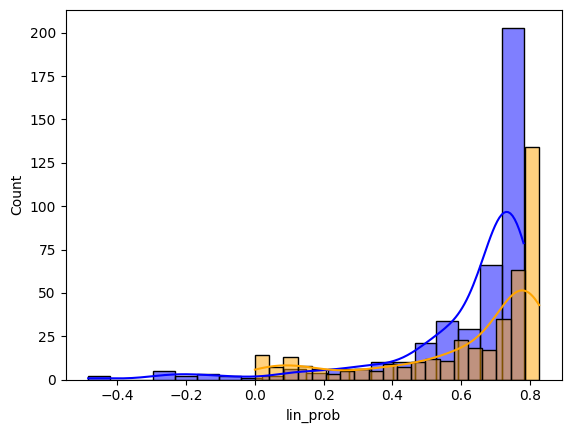

In [114]:
lin_model_cirr = LinearRegression()
df_cirr["survived"] = (df_cirr["Status"] != "D").astype(int)
lin_model_cirr.fit(X_cirr, df_cirr["survived"])
df_cirr["lin_prob"] = lin_model_cirr.predict(X_cirr)
df_cirr["log_prob"] = 1 - prob_cirr["D"]
sns.histplot(data = df_cirr["lin_prob"], bins = 20, kde = True, color = "blue")
sns.histplot(data = df_cirr["log_prob"], bins = 20, kde = True, color = "orange")

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?\
**The confusion matrix of the hard classification gets rid of stages 1 and 2, leaving only the signifianct 3 and 4. It is only decent at predicting stage 3, the rest is awful. Despite only being able to predict 3 and 4, it still manages to predict less right than wrong and predicts 3 as 4 more times. The predicted probabilities (predict_proba), however, does predict every class.**

In [120]:
X_multi_cirr = pd.get_dummies(
    df_cirr[["Edema", "Bilirubin"]],
    drop_first=True
)
y_multi_cirr = df_cirr["Stage"]
multi_model_cirr = LogisticRegression(solver="lbfgs", max_iter=1000)
multi_model_cirr.fit(X_multi_cirr, y_multi_cirr)
y_pred_cirr = multi_model_cirr.predict(X_multi_cirr)

tab_multi_cirr = pd.crosstab(y_multi_cirr, multi_model_cirr.predict(X_multi_cirr)) 
acc_multi_cirr = np.trace(tab_multi_cirr)/len(y_multi_cirr) # Accuracy
print(tab_multi_cirr)
pd.DataFrame(multi_model_cirr.predict_proba(X_multi_cirr), columns=multi_model_cirr.classes_)

col_0  3.0  4.0
Stage          
1.0     20    1
2.0     82   10
3.0    130   25
4.0     93   51


,1.0,2.0,3.0,4.0
0,0.000469,0.051112,0.137333,0.811086
1,0.068674,0.255047,0.397582,0.278697
2,0.039844,0.139561,0.340088,0.480506
3,0.035217,0.137519,0.338843,0.488421
4,0.035048,0.243195,0.404020,0.317737
...,...,...,...,...
407,0.066737,0.254682,0.398113,0.280468
408,0.072703,0.255726,0.396441,0.275130
409,0.059482,0.253060,0.399981,0.287478
410,0.074798,0.256039,0.395829,0.273335


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?\



**The derivative woul djust be bk. For every 1 unit change in the feature, the prediction changes by value of bk.**

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

**The deritive with respoect to the k-th feature is bk​p^​(1−p^​). As x changes, p will also change. When p is near 0 or 1, the prediction only changes by a little. Whereas if p were 0.5, the prediction changed the most. Therefore, with logistic regressions, the effect is more unpredictable than with a linear regression. Both the prediction and the slope depend on the x while in linear, only the prediction depends on x. Logistic is also harder to interpret. 0.25 is a good estimate of how a change in x affects the prediction.**

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

**A one unit change in x affects the log odds ration in a linear way, multiplying it by 1 unit of b. Breaking logistic into log odds ratio makes things more interpretable.**